## Cell 1: Cấu hình & Giải nén

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from IPython.display import FileLink

# --- CẤU HÌNH ---
# Tên thư mục gốc dataset của bạn trên Kaggle (cái folder Input bên phải)
# Nếu bạn đổi tên dataset, hãy cập nhật dòng này.
INPUT_ROOT = '/kaggle/input/isic-2019-skin-lesion-processed-8-classes'

IMG_SIZE = 300
BATCH_SIZE = 32
NUM_CLASSES = 8
EPOCHS_WARMUP = 15
EPOCHS_TOTAL = 100

# --- TỰ ĐỘNG DÒ TÌM FOLDER 'train' VÀ 'val' ---
print(f"[INFO] Đang quét tìm dữ liệu trong: {INPUT_ROOT}...")

TRAIN_DIR = None
VAL_DIR = None

# Hàm đi bộ qua các thư mục để tìm folder tên là 'train'
for root, dirs, files in os.walk(INPUT_ROOT):
    if 'train' in dirs:
        TRAIN_DIR = os.path.join(root, 'train')
        # Thử tìm val hoặc test nằm cùng cấp
        if 'val' in dirs:
            VAL_DIR = os.path.join(root, 'val')
        elif 'test' in dirs:
            VAL_DIR = os.path.join(root, 'test')
        print(f"✅ Đã tìm thấy folder dữ liệu tại: {root}")
        break

if TRAIN_DIR is None:
    print("❌ LỖI: Không tìm thấy folder 'train' nào cả! Hãy kiểm tra lại Input bên cột phải.")
else:
    # Kiểm tra xem folder Val có tìm thấy không
    if VAL_DIR is None:
        print("⚠️ Cảnh báo: Tìm thấy 'train' nhưng không thấy 'val' hay 'test'.")
        # (Nếu bạn dùng code tự chia train/val thì xử lý ở đây, nhưng dataset của bạn đã chia sẵn nên thường sẽ có)
    else:
        print(f"   - Train Dir: {TRAIN_DIR}")
        print(f"   - Val Dir:   {VAL_DIR}")
        print("[INFO] Sẵn sàng train!")

[INFO] Đang quét tìm dữ liệu trong: /kaggle/input/isic-2019-skin-lesion-processed-8-classes...
✅ Đã tìm thấy folder dữ liệu tại: /kaggle/input/isic-2019-skin-lesion-processed-8-classes
   - Train Dir: /kaggle/input/isic-2019-skin-lesion-processed-8-classes/train
   - Val Dir:   /kaggle/input/isic-2019-skin-lesion-processed-8-classes/val
[INFO] Sẵn sàng train!


## Cell 2: Data Generators (8 Classes)

In [3]:
from tensorflow.keras.applications.efficientnet import preprocess_input

print("[INFO] Setting up Data Generators...")

# Train: Augmentation mạnh để chống Overfitting
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

# Val: Chỉ preprocess
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # Quan trọng để vẽ Confusion Matrix đúng
)

CLASS_NAMES = list(train_generator.class_indices.keys())
print(f"[INFO] Classes detected ({NUM_CLASSES}): {CLASS_NAMES}")

[INFO] Setting up Data Generators...
Found 20264 images belonging to 8 classes.
Found 2533 images belonging to 8 classes.
[INFO] Classes detected (8): ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'scc', 'vasc']


## Cell 3: Xây dựng Model (EfficientNetB3)

In [4]:
def build_model():
    base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    predictions = Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=predictions)
    return base_model, model

base_model, model = build_model()
print("[INFO] Model built successfully.")

I0000 00:00:1769933172.111726      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
[INFO] Model built successfully.


## Cell 4: Thiết lập Callbacks (Lưu file liên tục)

In [5]:
# --- ĐỊNH NGHĨA TÊN MODEL CHUẨN (Để dùng xuyên suốt) ---
MODEL_NAME = 'efficientnet_b3_derma_v1.0_kaggle100e.keras'
MODEL_PATH = f'models/{MODEL_NAME}'

# Tạo folder lưu model nếu chưa có
os.makedirs('models', exist_ok=True)

# 1. Lưu model tốt nhất (Lưu file tạm/backup)
# Ta đặt tên là 'best_checkpoint.keras' để tránh nhầm với file final
checkpoint = ModelCheckpoint(
    'models/best_checkpoint.keras', 
    monitor='val_accuracy', 
    save_best_only=True, 
    mode='max', 
    verbose=1
)

# 2. Dừng sớm nếu không cải thiện
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=12, 
    restore_best_weights=True, # Quan trọng: Tự động khôi phục weights tốt nhất khi dừng
    verbose=1
)

# 3. Giảm learning rate khi bị kẹt
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=4, 
    min_lr=1e-6, 
    verbose=1
)

# 4. Lưu log train vào file CSV
csv_logger = CSVLogger('training_log.csv', append=True)

callbacks = [checkpoint, early_stop, reduce_lr, csv_logger]

## Cell 5: Giai đoạn 1 - Warm Up (15 Epochs)

In [6]:
print(f"[INFO] STAGE 1: Warm-up for {EPOCHS_WARMUP} epochs...")

base_model.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-3), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

history_1 = model.fit(
    train_generator,
    epochs=EPOCHS_WARMUP,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

[INFO] STAGE 1: Warm-up for 15 epochs...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


I0000 00:00:1769933195.800405     135 service.cc:152] XLA service 0x7d255421a8f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769933195.800448     135 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1769933199.603607     135 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1769933220.658976     135 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 982ms/step - accuracy: 0.5134 - loss: 1.7367
Epoch 1: val_accuracy improved from -inf to 0.61745, saving model to models/best_checkpoint.keras
634/634 ━━━━━━━━━━━━━━━━━━━━ 730s 1s/step - accuracy: 0.5134 - loss: 1.7362 - val_accuracy: 0.6174 - val_loss: 1.0504 - learning_rate: 0.0010
Epoch 2/15
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 713ms/step - accuracy: 0.6055 - loss: 1.0951
Epoch 2: val_accuracy improved from 0.61745 to 0.64627, saving model to models/best_checkpoint.keras
634/634 ━━━━━━━━━━━━━━━━━━━━ 463s 730ms/step - accuracy: 0.6055 - loss: 1.0951 - val_accuracy: 0.6463 - val_loss: 0.9829 - learning_rate: 0.0010
Epoch 3/15
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.6284 - loss: 1.0394
Epoch 3: val_accuracy did not improve from 0.64627
634/634 ━━━━━━━━━━━━━━━━━━━━ 395s 623ms/step - accuracy: 0.6284 - loss: 1.0394 - val_accuracy: 0.6439 - val_loss: 0.9723 - learning_rate: 0.0010
Epoch 4/15
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 602ms/step - accuracy:

## Cell 6: Giai đoạn 2 - Fine Tuning (85 Epochs)

In [7]:
print(f"[INFO] STAGE 2: Fine-tuning until epoch {EPOCHS_TOTAL}...")

# Mở khóa 50 lớp cuối
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-4), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

history_2 = model.fit(
    train_generator,
    epochs=EPOCHS_TOTAL,
    initial_epoch=EPOCHS_WARMUP,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

# Lưu model cuối cùng
model.save(MODEL_PATH) 
print(f"[INFO] Training complete. Model saved to: {MODEL_PATH}")

[INFO] STAGE 2: Fine-tuning until epoch 100...
Epoch 16/100


2026-02-01 09:52:59.107616: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-01 09:52:59.325756: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-01 09:52:59.663173: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-01 09:52:59.881717: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-01 09:53:00.475036: E external/local_xla/xla/stream_

577/634 ━━━━━━━━━━━━━━━━━━━━ 34s 607ms/step - accuracy: 0.6557 - loss: 0.9659

2026-02-01 09:59:14.870718: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-01 09:59:15.087036: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - accuracy: 0.6570 - loss: 0.9618
Epoch 16: val_accuracy improved from 0.67075 to 0.70470, saving model to models/best_checkpoint.keras
634/634 ━━━━━━━━━━━━━━━━━━━━ 480s 684ms/step - accuracy: 0.6571 - loss: 0.9617 - val_accuracy: 0.7047 - val_loss: 0.7946 - learning_rate: 1.0000e-04
Epoch 17/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.7043 - loss: 0.8193
Epoch 17: val_accuracy improved from 0.70470 to 0.72207, saving model to models/best_checkpoint.keras
634/634 ━━━━━━━━━━━━━━━━━━━━ 393s 620ms/step - accuracy: 0.7043 - loss: 0.8193 - val_accuracy: 0.7221 - val_loss: 0.7777 - learning_rate: 1.0000e-04
Epoch 18/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.7169 - loss: 0.7689
Epoch 18: val_accuracy improved from 0.72207 to 0.73233, saving model to models/best_checkpoint.keras
634/634 ━━━━━━━━━━━━━━━━━━━━ 391s 616ms/step - accuracy: 0.7169 - loss: 0.7689 - val_accuracy: 0.7323 - val_loss: 0.7247 - learning_rate: 1

## Cell 7: Vẽ Biểu Đồ History (Trực quan hóa)

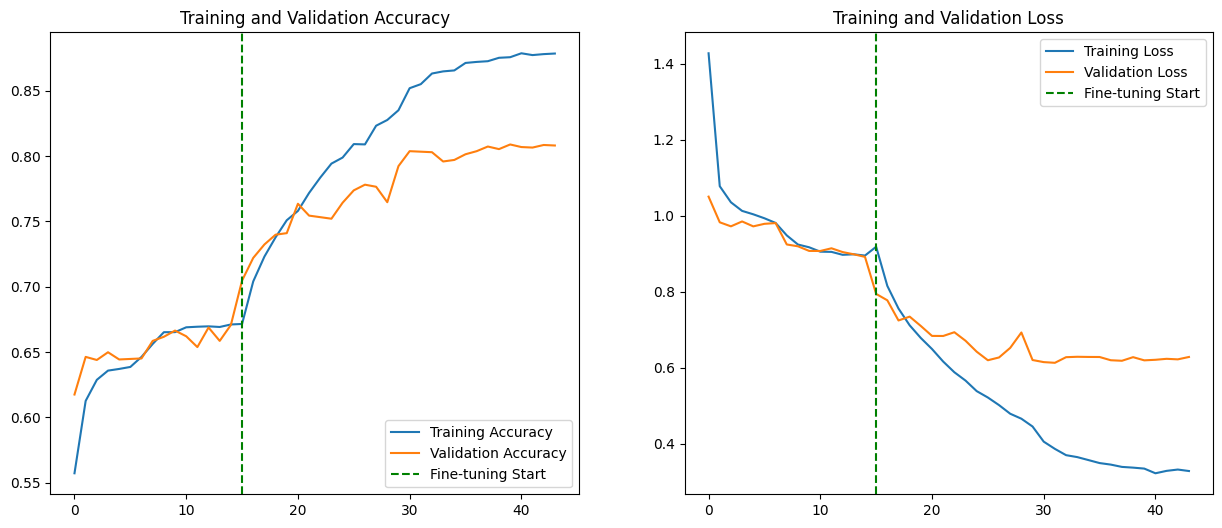

In [8]:
def plot_history(h1, h2):
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(15, 6))
    
    # Biểu đồ Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.axvline(x=EPOCHS_WARMUP, color='green', linestyle='--', label='Fine-tuning Start')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    # Biểu đồ Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.axvline(x=EPOCHS_WARMUP, color='green', linestyle='--', label='Fine-tuning Start')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    
    plt.savefig('history_plot.png') # Lưu ảnh để tải về
    plt.show()

plot_history(history_1, history_2)

## Cell 8: Đánh giá TTA (Test Time Augmentation)

In [10]:
from tensorflow.keras.models import load_model

print("[INFO] Evaluating with TTA (5 steps)...")

best_model = load_model(MODEL_PATH) 

TTA_STEPS = 5
preds_tta = []
true_labels = val_generator.classes

for i in range(TTA_STEPS):
    val_generator.reset()
    if i == 0:
        p = best_model.predict(val_generator, verbose=0)
    else:
        # Tạo generator TTA
        tta_datagen = ImageDataGenerator(
            preprocessing_function=tf.keras.applications.efficientnet.preprocess_input, # Đảm bảo đúng hàm preprocess
            rotation_range=20, horizontal_flip=True, vertical_flip=True
        )
        tta_gen = tta_datagen.flow_from_directory(
            VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE),
            batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
        )
        p = best_model.predict(tta_gen, verbose=0)
    preds_tta.append(p)

final_preds = np.mean(preds_tta, axis=0)
y_pred = np.argmax(final_preds, axis=1)

print("-" * 50)
print(f"Final TTA Accuracy: {accuracy_score(true_labels, y_pred)*100:.2f}%")
print("-" * 50)
print(classification_report(true_labels, y_pred, target_names=CLASS_NAMES))

[INFO] Evaluating with TTA (5 steps)...
Found 2533 images belonging to 8 classes.
Found 2533 images belonging to 8 classes.
Found 2533 images belonging to 8 classes.
Found 2533 images belonging to 8 classes.
--------------------------------------------------
Final TTA Accuracy: 83.58%
--------------------------------------------------
              precision    recall  f1-score   support

       akiec       0.69      0.66      0.67        87
         bcc       0.81      0.86      0.84       332
         bkl       0.71      0.71      0.71       262
          df       0.65      0.71      0.68        24
         mel       0.84      0.69      0.76       452
          nv       0.88      0.94      0.91      1287
         scc       0.72      0.60      0.66        63
        vasc       0.94      0.65      0.77        26

    accuracy                           0.84      2533
   macro avg       0.78      0.73      0.75      2533
weighted avg       0.83      0.84      0.83      2533



## Cell 9: Vẽ Ma trận nhầm lẫn (Confusion Matrix)

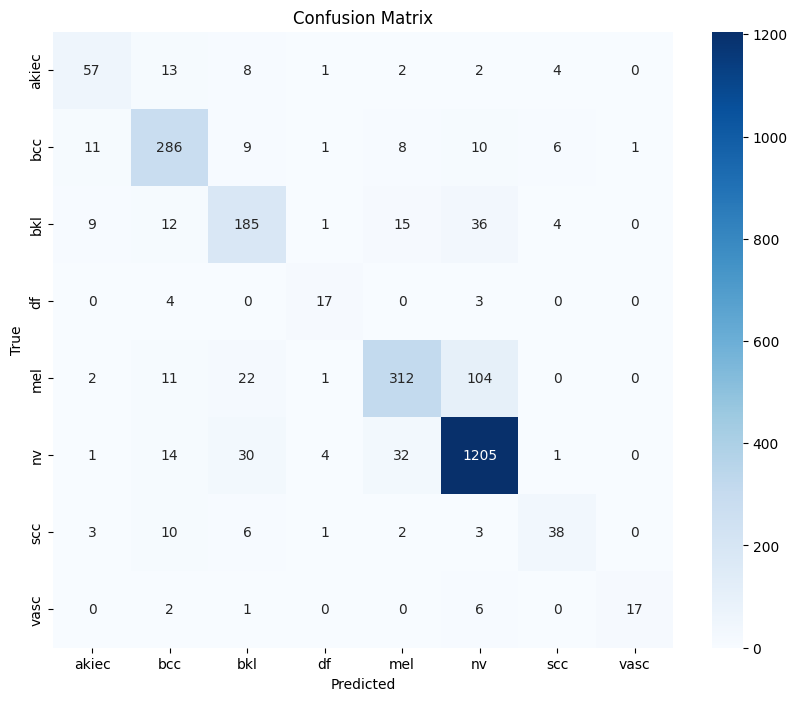

In [19]:
cm = confusion_matrix(true_labels, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

## Cell 10: Tạo Link Tải Về

In [23]:
from IPython.display import FileLink
import os

print("⬇️ CLICK TO DOWNLOAD FILES:")

# 1. Model chính (Tên xịn)
if os.path.exists(MODEL_PATH):
    display(FileLink(MODEL_PATH))
else:
    print(f"⚠️ Không tìm thấy file model: {MODEL_PATH}")

# 2. File Log
if os.path.exists('training_log.csv'):
    display(FileLink(r'training_log.csv'))

# 3. Biểu đồ & Ma trận (Nếu có)
if os.path.exists('history_plot.png'):
    display(FileLink(r'history_plot.png'))

if os.path.exists('confusion_matrix.png'):
    display(FileLink(r'confusion_matrix.png'))

⬇️ CLICK TO DOWNLOAD FILES:


/kaggle/working/models/efficientnet_b3_derma_v1.0_kaggle100e.keras

/kaggle/working/training_log.csv

/kaggle/working/history_plot.png

/kaggle/working/confusion_matrix.png